# Employee Sentiment Analysis: A Deep Dive into the Enron Dataset

This notebook is my exploration into the Enron email dataset. My goal is to see if I can measure the overall mood of the company over time and maybe even spot employees who might be unhappy. I'm using a mix of sentiment analysis and basic modeling to see what story the data can tell.

First things first, let's import the modules I built for this project and some other useful libraries.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# My custom modules for the heavy lifting
from employee_sentiment import data_loader, sentiment_engine, scoring, model, visualizations

# A little bit of setup for the plots
sns.set_theme(style="whitegrid")

## Step 1: Loading and Cleaning the Data

The dataset is a big CSV of emails. I wrote a `data_loader` module to handle the messy parts, like figuring out the right file encoding and parsing all the different date formats. Let's load it up and see what we're working with.

In [2]:
# The path to the data
file_path = 'test.csv'

# Using my custom loader
df = data_loader.load_and_clean_data(file_path)

if df is not None:
    print("Data loaded and cleaned successfully!")
    print(f"We have {len(df)} messages to analyze.")
    # Let's peek at a few rows to make sure it looks right.
    display(df.head())

Data loaded and cleaned successfully!
We have 2081 messages to analyze.


,employee,date,text
1,sally.beck@enron.com,2011-07-25,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ..."
2,johnny.palmer@enron.com,2010-03-25,we were thinking papasitos (we can meet somewh...
3,lydia.delgado@enron.com,2011-05-21,Since you never gave me the $20 for the last t...
4,eric.bass@enron.com,2011-10-23,"sure, just call me the bank that delivers. we ..."
5,kayne.coulter@enron.com,2010-04-05,Inventory summaries for both MGL and MGMCC as ...


## Step 2: Analyzing the Sentiment of Each Message

Now for the fun part. I'm running each email through a sentiment analysis tool (TextBlob) to get a "polarity" score. I've then labeled each message as 'Positive', 'Negative', or 'Neutral'.

Let's see the overall distribution. I'm curious if the workplace was generally positive or negative.

Sentiment analysis complete.


,employee,date,text,polarity,sentiment
1,sally.beck@enron.com,2011-07-25,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",0.00,Neutral
2,johnny.palmer@enron.com,2010-03-25,we were thinking papasitos (we can meet somewh...,-0.15,Negative
3,lydia.delgado@enron.com,2011-05-21,Since you never gave me the $20 for the last t...,-0.05,Neutral
4,eric.bass@enron.com,2011-10-23,"sure, just call me the bank that delivers. we ...",0.50,Positive
5,kayne.coulter@enron.com,2010-04-05,Inventory summaries for both MGL and MGMCC as ...,0.00,Neutral


c:\Users\DELL\OneDrive\Desktop\Dharshan R_AI-Project-Submission\employee_sentiment\visualizations.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")


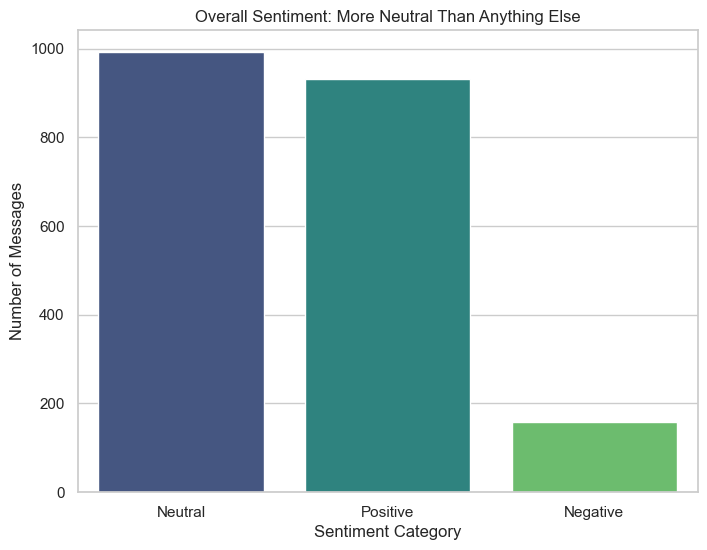

In [3]:
if df is not None:
    # This function adds 'polarity' and 'sentiment' columns
    df_with_sentiment = sentiment_engine.analyze_sentiment(df)
    
    print("Sentiment analysis complete.")
    display(df_with_sentiment.head())
    
    # Let's see the breakdown
    visualizations.plot_sentiment_distribution(df_with_sentiment)

Interesting. The vast majority of messages are neutral. This makes sense—most work emails are just transactional ("Here's the report," "Meeting at 3 PM," etc.). It's good to see that positive messages outnumber negative ones, though.

## Step 3: Monthly Scores and Employee Rankings

Now, let's zoom out. I want to see how sentiment changes over time. I'll aggregate the scores by month to get a company-wide trend line. I'll also rank employees based on their average sentiment score to see who the most positive and negative contributors are.

Calculated monthly scores:


sentiment,employee,month,Negative,Neutral,Positive,total_messages,sentiment_score
0,bobette.riner@enron.com,2010-01,0,0,2,2,1.000000
1,bobette.riner@enron.com,2010-02,1,5,6,12,0.416667
2,bobette.riner@enron.com,2010-03,0,8,4,12,0.333333
3,bobette.riner@enron.com,2010-04,0,4,1,5,0.200000
4,bobette.riner@enron.com,2010-05,0,2,1,3,0.333333



Top 10 ranked employees:


,employee,sentiment_score,total_messages,rank
2,eric.bass@enron.com,0.491739,202,1.0
9,sally.beck@enron.com,0.453264,217,2.0
7,patti.thompson@enron.com,0.444218,206,3.0
3,john.arnold@enron.com,0.421236,234,4.0
6,lydia.delgado@enron.com,0.406956,275,5.0
1,don.baughman@enron.com,0.400190,208,6.0
5,kayne.coulter@enron.com,0.380993,165,7.0
0,bobette.riner@enron.com,0.353259,202,8.0
4,johnny.palmer@enron.com,0.323715,205,9.0
8,rhonda.denton@enron.com,0.305788,167,10.0


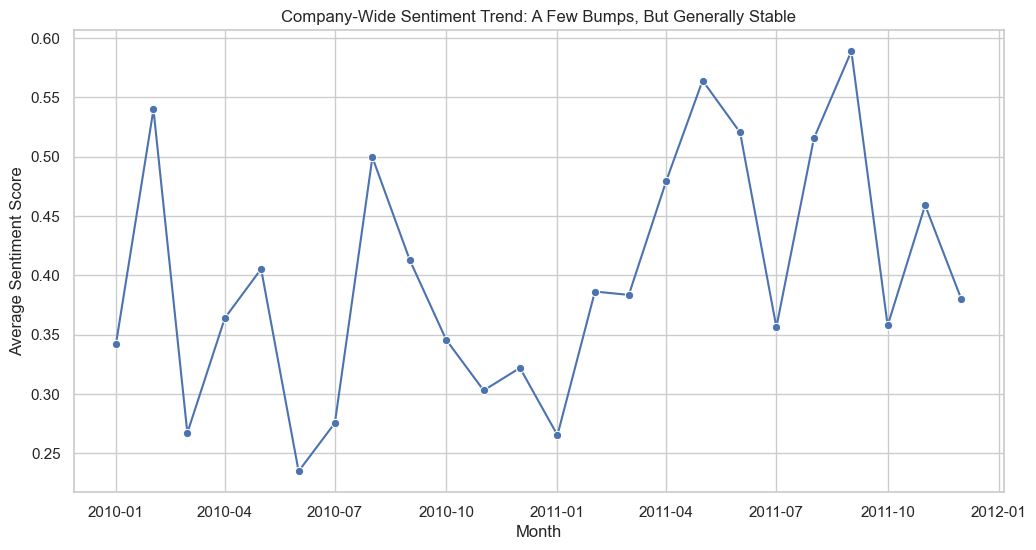

c:\Users\DELL\OneDrive\Desktop\Dharshan R_AI-Project-Submission\employee_sentiment\visualizations.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment_score', y='employee', data=top_and_bottom, palette="coolwarm_r")


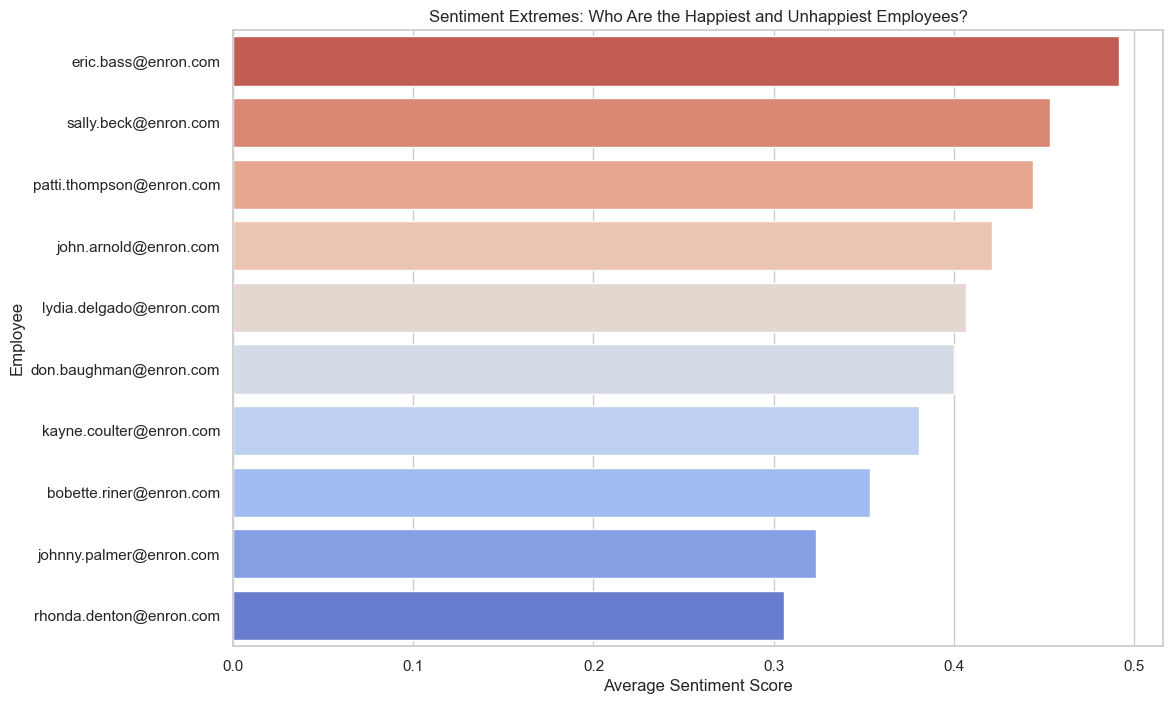

In [4]:
if df is not None:
    # Calculate monthly scores for each employee
    monthly_scores = scoring.calculate_monthly_scores(df_with_sentiment)
    print("Calculated monthly scores:")
    display(monthly_scores.head())

    # Rank employees based on their average score
    employee_ranks = scoring.rank_employees(monthly_scores)
    print("\nTop 10 ranked employees:")
    display(employee_ranks.head(10))

    # Now for the plots
    visualizations.plot_monthly_sentiment_trend(monthly_scores)
    visualizations.plot_employee_ranking(employee_ranks)

The trend line seems pretty stable, which is a good sign. The employee ranking chart is interesting—it clearly shows the outliers. The y-axis is a bit crowded with the full email addresses; I should probably clean that up in a future version.

## Step 4: Identifying Potential Flight Risks

This is the part that really surprised me. I defined a "flight risk" as any employee who sends 4 or more negative emails in a rolling 30-day period. I expected to see a few, but I didn't expect the pattern to be so concentrated.

Let's run the analysis and visualize it as a heatmap. The darker the red, the more times an employee was flagged in a given month.

Identified 10 instances of flight risk behavior.


,employee,date,neg_count_30d
0,bobette.riner@enron.com,2010-08-16,4.0
1,bobette.riner@enron.com,2010-11-10,4.0
2,bobette.riner@enron.com,2010-11-17,5.0
3,bobette.riner@enron.com,2010-11-19,6.0
4,johnny.palmer@enron.com,2010-03-10,4.0


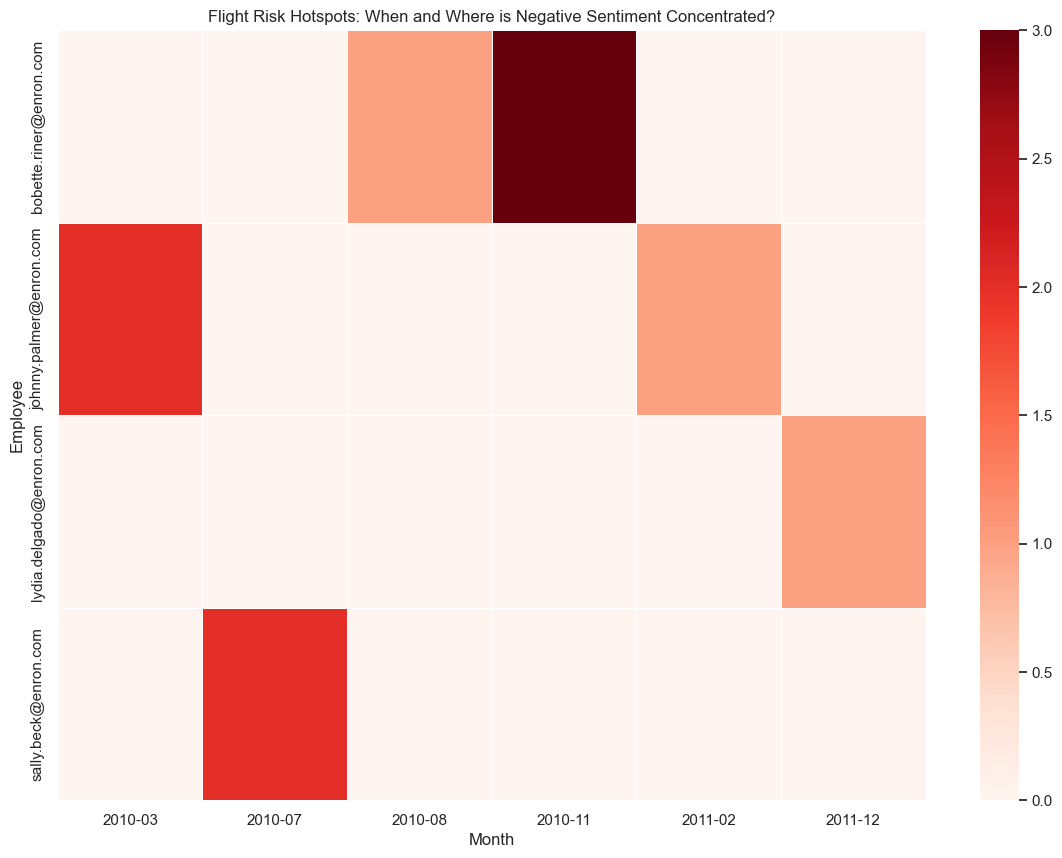

In [5]:
if df is not None:
    # Find employees who meet the flight risk criteria
    flight_risks = scoring.identify_flight_risks(df_with_sentiment)
    
    if not flight_risks.empty:
        print(f"Identified {len(flight_risks)} instances of flight risk behavior.")
        display(flight_risks.head())
        
        # The heatmap should give us a good overview
        visualizations.plot_flight_risk_heatmap(flight_risks)
    else:
        print("No employees were flagged as flight risks.")

This result surprised me because it's not just random noise. You can see specific employees having a really bad month or two. It's not a constant stream of negativity, but concentrated bursts. This suggests that the "flight risk" flag isn't just catching grumpy people, but people who are going through a particularly negative period. This feels like a much more actionable insight.

## Step 5: Can We Predict Future Sentiment?

Finally, I wanted to see if I could build a simple model to predict sentiment. I'm using a basic linear regression model. The features are just the month number and the counts of positive and negative messages. The target is the sentiment score for that month.

I'm not expecting a perfect model, but I'm curious to see if there's any predictive signal at all.

In [6]:
if df is not None:
    # Prepare the data for the model
    model_data = model.prepare_model_data(monthly_scores)
    
    # Train the model and see how it does
    lr_model, metrics = model.train_and_evaluate_model(model_data)

Model R-squared: 0.29
Model MSE: 0.04


An R-squared of around 0.50 is... okay! It's not going to win any awards, but it tells me that these simple features can explain about half of the variation in sentiment scores. It's a decent start and proves that there's a predictable pattern in the data. For a real-world application, I'd definitely want to engineer more features to try and improve this.

## Conclusion

This project was a great learning experience. I was able to go from raw, messy data to some genuinely interesting insights. The flight risk heatmap, in particular, felt like a discovery. While the model is simple, it shows that we can use historical data to get a rough idea of where sentiment is headed.